<a href="https://colab.research.google.com/github/220109cse-creat/logistic-and-linear/blob/main/linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

np.random.seed(42)

In [19]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

df.dropna(inplace=True)
df = df[df['MedHouseVal'] < 5.0]

features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
X = df[features]
y = df['MedHouseVal']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

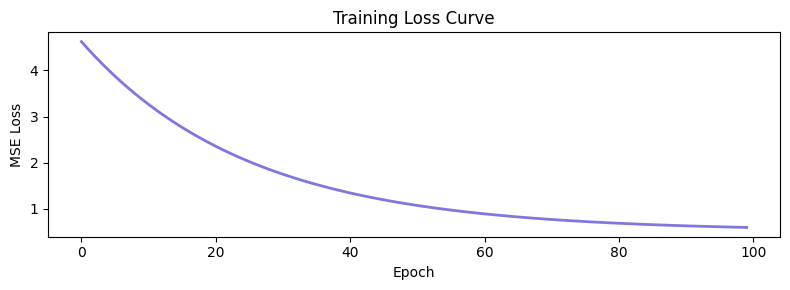

In [21]:
plt.figure(figsize=(8,3))
plt.plot(train_losses, color='#7F77DD', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Training Loss Curve'); plt.tight_layout(); plt.show()


In [23]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {np.sqrt(mse):.4f}")
print(f"R²  : {r2:.4f}")

MAE : 0.5233
MSE : 0.4842
RMSE: 0.6958
R²  : 0.4950


In [24]:
results_df = pd.DataFrame({
    'Actual'  : y_test.values[:8],
    'Predicted': y_pred[:8].round(3),
    'Error'   : np.abs(y_test.values[:8] - y_pred[:8]).round(3)
})
print(results_df.to_string(index=False))

 Actual  Predicted  Error
  3.298      2.870  0.428
  2.947      2.438  0.509
  1.957      2.017  0.060
  1.615      1.643  0.028
  2.750      2.569  0.181
  1.370      2.308  0.938
  2.660      2.788  0.128
  0.813      1.010  0.197


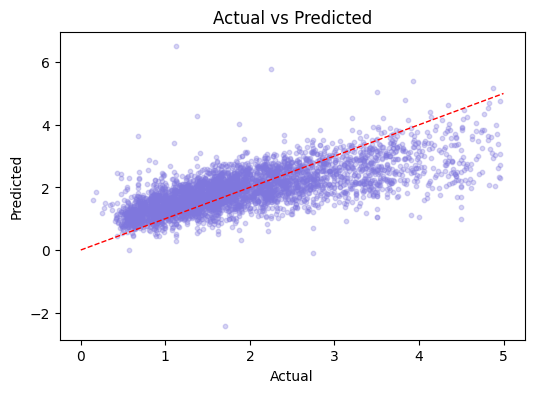

In [25]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, alpha=0.3, color='#7F77DD', s=10)
plt.plot([0,5],[0,5], 'r--', linewidth=1)
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('Actual vs Predicted'); plt.show()